# Module 1 Coding Assignment: Exploring Neural Network Parameters
This exercise serves as a continuation to the Example 3 we saw in class. We'll continue with the handwritten digit recognition task and explore how the number of hidden layers, the number of nodes in a single layer, and various activation functions impact the performance of our neural network.

# Instructions
Follow through the below steps, run the code provided, and observe how different configurations of hyper parameters affect performance of the neural network.


## Step 1: Data Preparation
We'll use the MNIST dataset of handwritten digits like we did in class. The MNIST dataset is already included in Keras.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.utils import to_categorical

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape the data to match the input expected by the neural network and normalize pixel values
x_train = x_train.reshape((60000, 28 * 28)).astype('float32') / 255
x_test = x_test.reshape((10000, 28 * 28)).astype('float32') / 255

# One-hot encode the labels to create a binary matrix representation
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Step 2: Building the Neural Network
Define a function to build the neural network model with customizable parameters.





In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.optimizers import Adam

# Function to build a neural network model
def build_model(hidden_layers=1, nodes_per_layer=64, activation='relu'):
    # Initialize a Sequential model
    model = Sequential()

    # Add the first hidden layer with the specified number of nodes and activation function
    model.add(Dense(nodes_per_layer, input_shape=(28 * 28,), activation=activation))

    # Add additional hidden layers as specified
    for _ in range(hidden_layers - 1):
        model.add(Dense(nodes_per_layer, activation=activation))

    # Add the output layer with 10 nodes (one for each digit 0-9) and softmax activation function
    model.add(Dense(10, activation='softmax'))

    # Compile the model with Adam optimizer and categorical crossentropy loss function
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

    return model


## Step 3: Training the Model
Define a function that train the model with different configurations and evaluate its performance.



In [ ]:
# Function to train and evaluate the model
def train_and_evaluate(hidden_layers, nodes_per_layer, activation, epochs=5, batch_size=128):
    # Build the model with the specified parameters
    model = build_model(hidden_layers, nodes_per_layer, activation)

    # Train the model and store the training history
    history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test), verbose=2)

    # Evaluate the model on the test data
    loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

    return history, accuracy


### Example configuration: 2 hidden layers, 128 nodes per layer, ReLU activation function

In [ ]:
history, accuracy = train_and_evaluate(hidden_layers=2, nodes_per_layer=128, activation='relu')
print(f'Accuracy: {accuracy*100:.2f}%')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 - 7s - 15ms/step - accuracy: 0.9085 - loss: 0.3209 - val_accuracy: 0.9580 - val_loss: 0.1450
Epoch 2/5
469/469 - 7s - 16ms/step - accuracy: 0.9633 - loss: 0.1241 - val_accuracy: 0.9692 - val_loss: 0.1048
Epoch 3/5
469/469 - 3s - 6ms/step - accuracy: 0.9745 - loss: 0.0858 - val_accuracy: 0.9720 - val_loss: 0.0956
Epoch 4/5
469/469 - 4s - 8ms/step - accuracy: 0.9802 - loss: 0.0640 - val_accuracy: 0.9743 - val_loss: 0.0863
Epoch 5/5
469/469 - 4s - 9ms/step - accuracy: 0.9837 - loss: 0.0516 - val_accuracy: 0.9783 - val_loss: 0.0742
Accuracy: 97.83%


## Step 4: Experiment with Different Configurations
Now, it's your turn to experiment with the network architecture.



### Task 1: Modify the Number of Hidden Layers

Try out different number of hidden layers to see how it affects the model's performance.

In [ ]:
hidden_layer_configs = [1, 2, 3, 4]
hidden_layer_results = []

# Loop through different configurations for the number of hidden layers
for hl in hidden_layer_configs:
    # Train and evaluate the model with the current number of hidden layers
    history, accuracy = train_and_evaluate(hidden_layers=hl, nodes_per_layer=64, activation='relu')
    hidden_layer_results.append((hl, history, accuracy))
    print(f'Hidden Layers: {hl}, Accuracy: {accuracy*100:.2f}%')


Epoch 1/5
469/469 - 3s - 6ms/step - accuracy: 0.8869 - loss: 0.4154 - val_accuracy: 0.9346 - val_loss: 0.2314
Epoch 2/5
469/469 - 2s - 4ms/step - accuracy: 0.9413 - loss: 0.2083 - val_accuracy: 0.9473 - val_loss: 0.1782
Epoch 3/5
469/469 - 3s - 6ms/step - accuracy: 0.9546 - loss: 0.1607 - val_accuracy: 0.9569 - val_loss: 0.1444
Epoch 4/5
469/469 - 2s - 5ms/step - accuracy: 0.9622 - loss: 0.1308 - val_accuracy: 0.9638 - val_loss: 0.1253
Epoch 5/5
469/469 - 2s - 4ms/step - accuracy: 0.9674 - loss: 0.1104 - val_accuracy: 0.9688 - val_loss: 0.1132
Hidden Layers: 1, Accuracy: 96.88%
Epoch 1/5
469/469 - 3s - 7ms/step - accuracy: 0.8932 - loss: 0.3826 - val_accuracy: 0.9472 - val_loss: 0.1833
Epoch 2/5
469/469 - 3s - 6ms/step - accuracy: 0.9520 - loss: 0.1649 - val_accuracy: 0.9597 - val_loss: 0.1384
Epoch 3/5
469/469 - 2s - 5ms/step - accuracy: 0.9643 - loss: 0.1207 - val_accuracy: 0.9655 - val_loss: 0.1118
Epoch 4/5
469/469 - 2s - 5ms/step - accuracy: 0.9714 - loss: 0.0964 - val_accuracy: 0

### Task 2: Change the Number of Nodes in a Layer

Try out different number of nodes in each layer.

In [ ]:
nodes_per_layer_configs = [32, 64, 128, 256]
nodes_per_layer_results = []

# Loop through different configurations for the number of nodes per hidden layer
for nodes in nodes_per_layer_configs:
    # Train and evaluate the model with the current number of nodes per layer
    history, accuracy = train_and_evaluate(hidden_layers=2, nodes_per_layer=nodes, activation='relu')
    nodes_per_layer_results.append((nodes, history, accuracy))
    print(f'Nodes per Layer: {nodes}, Accuracy: {accuracy*100:.2f}%')


Epoch 1/5
469/469 - 3s - 6ms/step - accuracy: 0.8578 - loss: 0.5066 - val_accuracy: 0.9296 - val_loss: 0.2522
Epoch 2/5
469/469 - 2s - 5ms/step - accuracy: 0.9372 - loss: 0.2214 - val_accuracy: 0.9448 - val_loss: 0.1923
Epoch 3/5
469/469 - 2s - 3ms/step - accuracy: 0.9505 - loss: 0.1727 - val_accuracy: 0.9497 - val_loss: 0.1677
Epoch 4/5
469/469 - 3s - 7ms/step - accuracy: 0.9576 - loss: 0.1462 - val_accuracy: 0.9537 - val_loss: 0.1541
Epoch 5/5
469/469 - 2s - 4ms/step - accuracy: 0.9630 - loss: 0.1265 - val_accuracy: 0.9594 - val_loss: 0.1369
Nodes per Layer: 32, Accuracy: 95.94%
Epoch 1/5
469/469 - 3s - 7ms/step - accuracy: 0.8886 - loss: 0.3926 - val_accuracy: 0.9441 - val_loss: 0.1851
Epoch 2/5
469/469 - 2s - 4ms/step - accuracy: 0.9507 - loss: 0.1669 - val_accuracy: 0.9560 - val_loss: 0.1485
Epoch 3/5
469/469 - 3s - 6ms/step - accuracy: 0.9630 - loss: 0.1238 - val_accuracy: 0.9637 - val_loss: 0.1210
Epoch 4/5
469/469 - 2s - 5ms/step - accuracy: 0.9705 - loss: 0.0997 - val_accuracy

### Task 3: Activation Functions
Try using different activation functions such as `tanh` or `sigmoid` instead of `relu`.

In [ ]:
activation_functions = ['relu', 'sigmoid', 'tanh']
activation_function_results = []

# Loop through different activation functions
for activation in activation_functions:
    # Train and evaluate the model with the current activation function
    history, accuracy = train_and_evaluate(hidden_layers=2, nodes_per_layer=64, activation=activation)
    activation_function_results.append((activation, history, accuracy))
    print(f'Activation Function: {activation}, Accuracy: {accuracy*100:.2f}%')


Epoch 1/5
469/469 - 3s - 7ms/step - accuracy: 0.8903 - loss: 0.3843 - val_accuracy: 0.9444 - val_loss: 0.1887
Epoch 2/5
469/469 - 2s - 5ms/step - accuracy: 0.9515 - loss: 0.1654 - val_accuracy: 0.9602 - val_loss: 0.1363
Epoch 3/5
469/469 - 3s - 6ms/step - accuracy: 0.9632 - loss: 0.1239 - val_accuracy: 0.9657 - val_loss: 0.1136
Epoch 4/5
469/469 - 2s - 5ms/step - accuracy: 0.9703 - loss: 0.0984 - val_accuracy: 0.9705 - val_loss: 0.0995
Epoch 5/5
469/469 - 3s - 5ms/step - accuracy: 0.9756 - loss: 0.0815 - val_accuracy: 0.9719 - val_loss: 0.0971
Activation Function: relu, Accuracy: 97.19%
Epoch 1/5
469/469 - 3s - 7ms/step - accuracy: 0.7784 - loss: 0.9700 - val_accuracy: 0.9067 - val_loss: 0.3816
Epoch 2/5
469/469 - 3s - 5ms/step - accuracy: 0.9146 - loss: 0.3128 - val_accuracy: 0.9301 - val_loss: 0.2518
Epoch 3/5
469/469 - 3s - 5ms/step - accuracy: 0.9351 - loss: 0.2293 - val_accuracy: 0.9422 - val_loss: 0.2013
Epoch 4/5
469/469 - 3s - 7ms/step - accuracy: 0.9468 - loss: 0.1861 - val_ac

## Step 5: Visualizing the Results
Visualize the training history for one of the experiments.

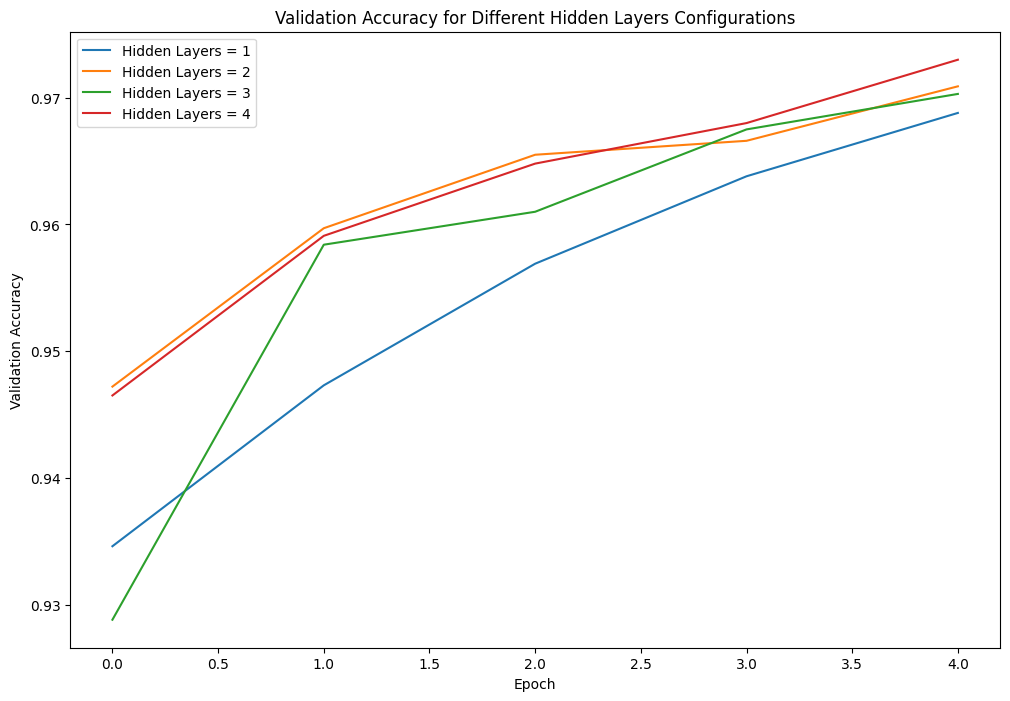

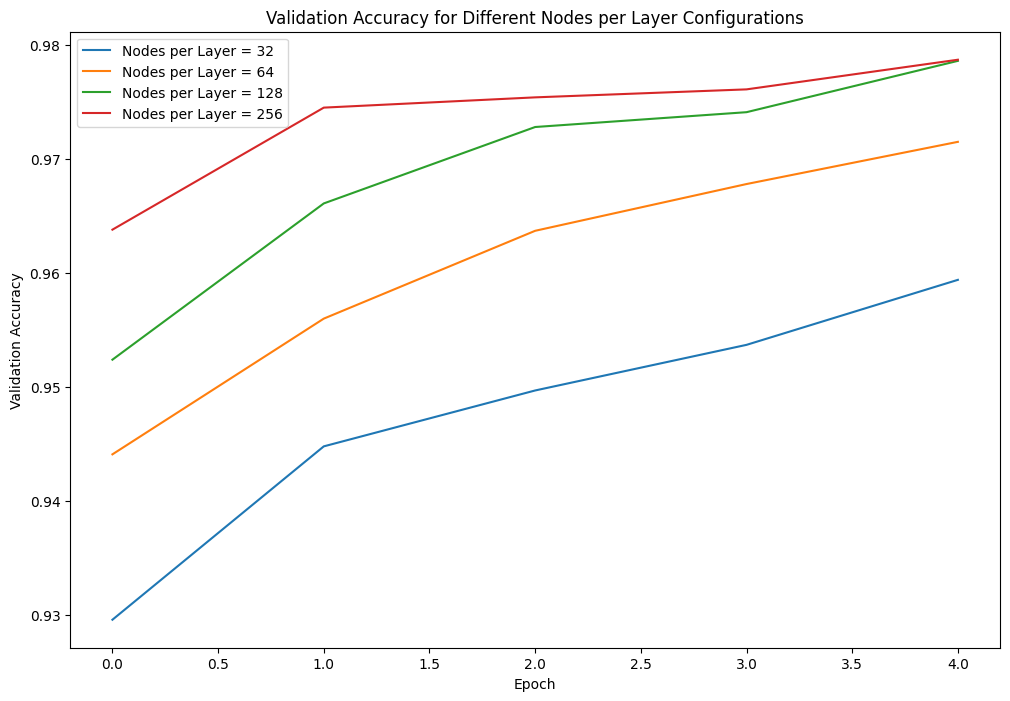

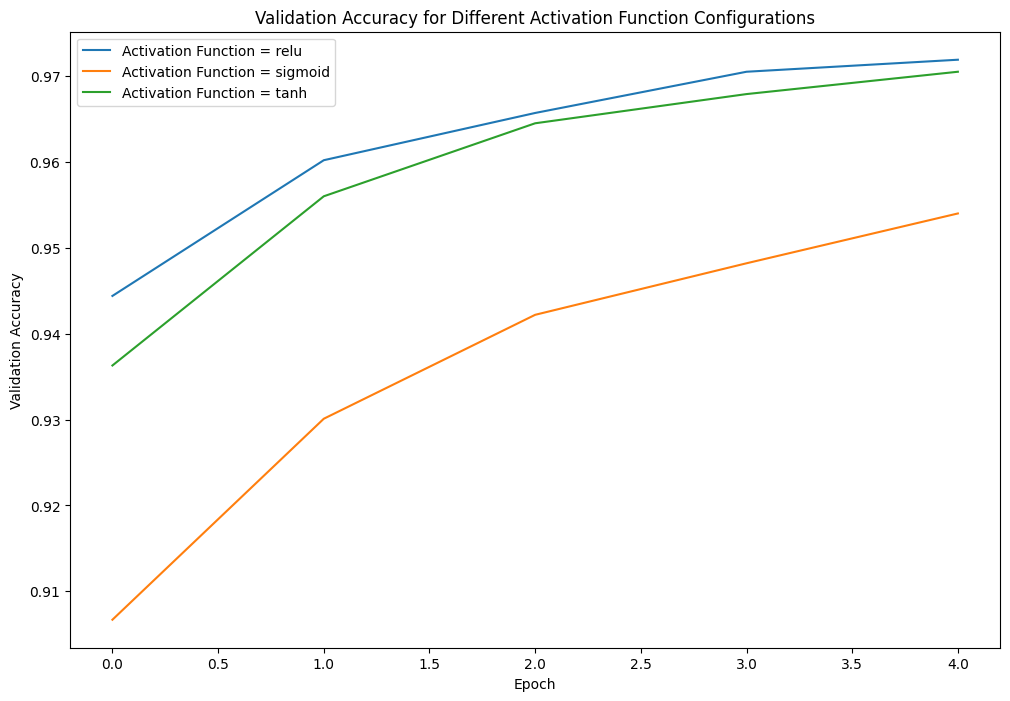

In [ ]:
import matplotlib.pyplot as plt

# Function to plot training history for different configurations
def plot_experiment_results(results, parameter_name):
    plt.figure(figsize=(12, 8))

    for param_value, history, _ in results:
        plt.plot(history.history['val_accuracy'], label=f'{parameter_name} = {param_value}')

    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.title(f'Validation Accuracy for Different {parameter_name} Configurations')
    plt.show()

# Plot results for the number of hidden layers
plot_experiment_results(hidden_layer_results, 'Hidden Layers')

# Plot results for the number of nodes per layer
plot_experiment_results(nodes_per_layer_results, 'Nodes per Layer')

# Plot results for the activation functions
plot_experiment_results(activation_function_results, 'Activation Function')


## Step 6: Observations and Analysis
* Record your observations for each experiment.
* Analyze how changes in the network architecture impacted the model's performance.
* Discuss why certain configurations performed better or worse than others.


### Put your answer here


# Summary

In this exercise, we explored the impact of different neural network architectures on the performance of a handwritten digit recognition task using the MNIST dataset.

This exercise demonstrated the importance of carefully choosing the hyperparameters of a neural network, including the number of hidden layers, nodes per layer, and activation function, to achieve optimal performance on a given task. The best configuration depends on the complexity of the data and the desired level of accuracy. Experimentation and careful evaluation are crucial to finding the optimal architecture for a specific problem.